In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,plot_tree 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,log_loss
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import os
os.chdir("/home/pgcp-ai/MachineLearning/Cases/Glass_Identification/")

In [2]:
glass = pd.read_csv("Glass.csv")
glass

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,building_windows_float_processed
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,building_windows_float_processed
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,building_windows_float_processed
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,building_windows_float_processed
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,building_windows_float_processed
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,headlamps
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,headlamps
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,headlamps
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,headlamps


In [3]:
glass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    object 
dtypes: float64(9), object(1)
memory usage: 16.8+ KB


In [4]:
glass.isna().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [5]:
le = LabelEncoder()

In [7]:
glass['Type'] = le.fit_transform(glass['Type'])

In [14]:
X,y = glass.drop("Type", axis = 1), glass["Type"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state = 26, stratify = y)

In [15]:
depths = [1,2,3,4,5,6]
splits = []
scores = []
for d in tqdm(depths):
    dtc = DecisionTreeClassifier(criterion='gini',max_depth=d,random_state=26)
    dtc.fit(X_train, y_train)
    y_pred_prob = dtc.predict_proba(X_test)
    y_pred = dtc.predict(X_test)
    scores.append([d,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Depth","Log Loss","Accuracy"])
df_scores.sort_values('Log Loss')

100%|████████████████████████████████████████████| 6/6 [00:00<00:00, 106.35it/s]


,Depth,Log Loss,Accuracy
0,1,1.719655,0.476923
2,3,2.998810,0.676923
1,2,3.060609,0.661538
3,4,3.950324,0.723077
4,5,5.381715,0.692308
5,6,8.473752,0.692308


In [16]:
depths = [1,2,3,4,5,6]
splits = [2,5,10,20,30]
scores = []
for s in tqdm(splits):
    dtc = DecisionTreeClassifier(criterion='gini',min_samples_split=s,random_state=26)
    dtc.fit(X_train, y_train)
    y_pred_prob = dtc.predict_proba(X_test)
    y_pred = dtc.predict(X_test)
    scores.append([s,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Min Samples in each Node","Log Loss","Accuracy"])
df_scores.sort_values('Log Loss')

100%|████████████████████████████████████████████| 5/5 [00:00<00:00, 107.41it/s]


,Min Samples in each Node,Log Loss,Accuracy
4,30,2.782332,0.753846
3,20,3.343250,0.692308
2,10,7.981790,0.661538
1,5,9.471269,0.707692
0,2,11.090355,0.692308


In [17]:
depths = [1,2,3,4,5,6]
splits = [2,5,10,20,30]
scores = []
for s in tqdm(splits):
    for d in depths:
        dtc = DecisionTreeClassifier(criterion='gini',min_samples_split=s,random_state=26,max_depth=d)
        dtc.fit(X_train, y_train)
        y_pred_prob = dtc.predict_proba(X_test)
        y_pred = dtc.predict(X_test)
        scores.append([d,s,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Depth","Min Samples in each Node","Log Loss","Accuracy"])
df_scores.sort_values('Log Loss')

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 23.08it/s]


,Depth,Min Samples in each Node,Log Loss,Accuracy
0,1,2,1.719655,0.476923
24,1,30,1.719655,0.476923
18,1,20,1.719655,0.476923
6,1,5,1.719655,0.476923
12,1,10,1.719655,0.476923
27,4,30,2.417057,0.723077
26,3,30,2.457259,0.692308
25,2,30,2.519059,0.676923
29,6,30,2.782332,0.753846
28,5,30,2.850560,0.723077


In [18]:
depths = [1,2,3,4,5,6]
splits = [1,5,8,10,20]
scores = []
for s in tqdm(splits):
    dtc = DecisionTreeClassifier(criterion='gini',min_samples_leaf=s,random_state=26)
    dtc.fit(X_train, y_train)
    y_pred_prob = dtc.predict_proba(X_test)
    y_pred = dtc.predict(X_test)
    scores.append([s,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Min Leaves in each Node","Log Loss","Accuracy"])
df_scores.sort_values(['Log Loss', 'Accuracy'], ascending = [True, False])

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 81.53it/s]


,Min Leaves in each Node,Log Loss,Accuracy
4,20,2.531290,0.538462
3,10,2.787265,0.753846
2,8,2.803695,0.738462
1,5,4.823313,0.707692
0,1,11.090355,0.692308


In [35]:
depths_old = np.arange(1,7)
splits_old = np.arange(2,25)
leaves_old = np.arange(1,25)

depths = [1,2,3,5,None]
splits = [2,4,8,10,20,30,50,100]
leaves  = [1,4,8,10,20,30,45,46,50,100]

scores = []
for d in tqdm(depths):
    for s in splits:
        for l in leaves:     
            dtc = DecisionTreeClassifier(criterion='gini',min_samples_split=s,random_state=26,max_depth=d,min_samples_leaf=l)
            dtc.fit(X_train, y_train)
            y_pred_prob = dtc.predict_proba(X_test)
            y_pred = dtc.predict(X_test)
            scores.append([d,s,l,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
df_scores = pd.DataFrame(scores,columns=["Depth","Min Samples in each Node to Split",'Min Samples in each Leaf Node',"Log Loss","Accuracy"])
df_scores.sort_values('Log Loss')

100%|█████████████████████████████████████████████| 5/5 [00:02<00:00,  2.23it/s]


,Depth,Min Samples in each Node to Split,Min Samples in each Leaf Node,Log Loss,Accuracy
287,5.0,20,46,1.208317,0.523077
217,3.0,30,46,1.208317,0.523077
337,NaN,4,46,1.208317,0.523077
327,NaN,2,46,1.208317,0.523077
227,3.0,50,46,1.208317,0.523077
...,...,...,...,...,...
351,NaN,10,4,5.864406,0.707692
350,NaN,10,1,7.981790,0.661538
340,NaN,8,1,8.962651,0.692308
330,NaN,4,1,9.471269,0.707692


In [36]:
bm = DecisionTreeClassifier(random_state=26, max_depth = 5, min_samples_split=20, min_samples_leaf=46)
bm.fit(X, y)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=46, min_samples_split=20,
                       random_state=26)

In [37]:
list(X.columns)

['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

In [45]:
l1 = le.inverse_transform(le.classes_)
l1

array([0, 1, 2, 3, 4, 5])

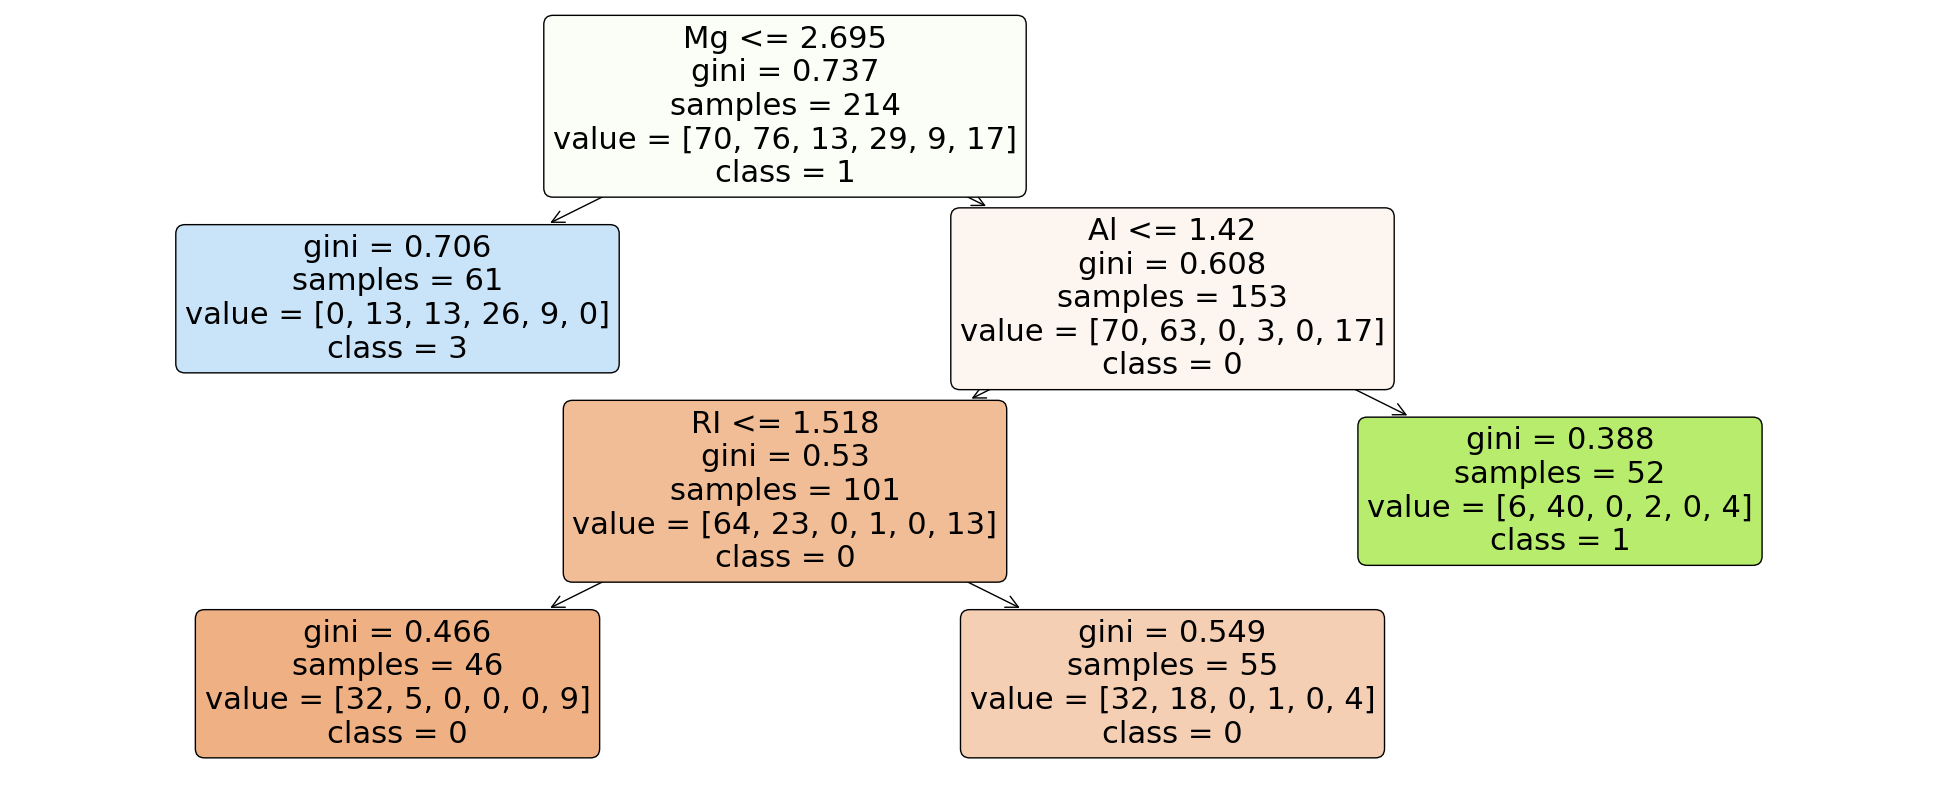

In [63]:
plt.figure(figsize = (25,10))
plot_tree(bm,filled=True, rounded = True,feature_names=list(X.columns),class_names=['0','1','2','3','4','5'])
plt.show()

In [48]:
bm.feature_importances_

array([0.04453728, 0.        , 0.50250775, 0.45295498, 0.        ,
       0.        , 0.        , 0.        , 0.        ])

In [50]:
df_imp = pd.DataFrame({'feature':X.columns, 'Importance': bm.feature_importances_})
df_imp

,feature,Importance
0,RI,0.044537
1,Na,0.000000
2,Mg,0.502508
3,Al,0.452955
4,Si,0.000000
5,K,0.000000
6,Ca,0.000000
7,Ba,0.000000
8,Fe,0.000000


In [51]:
df_imp = df_imp.sort_values("Importance")
df_imp

,feature,Importance
1,Na,0.000000
4,Si,0.000000
5,K,0.000000
6,Ca,0.000000
7,Ba,0.000000
8,Fe,0.000000
0,RI,0.044537
3,Al,0.452955
2,Mg,0.502508


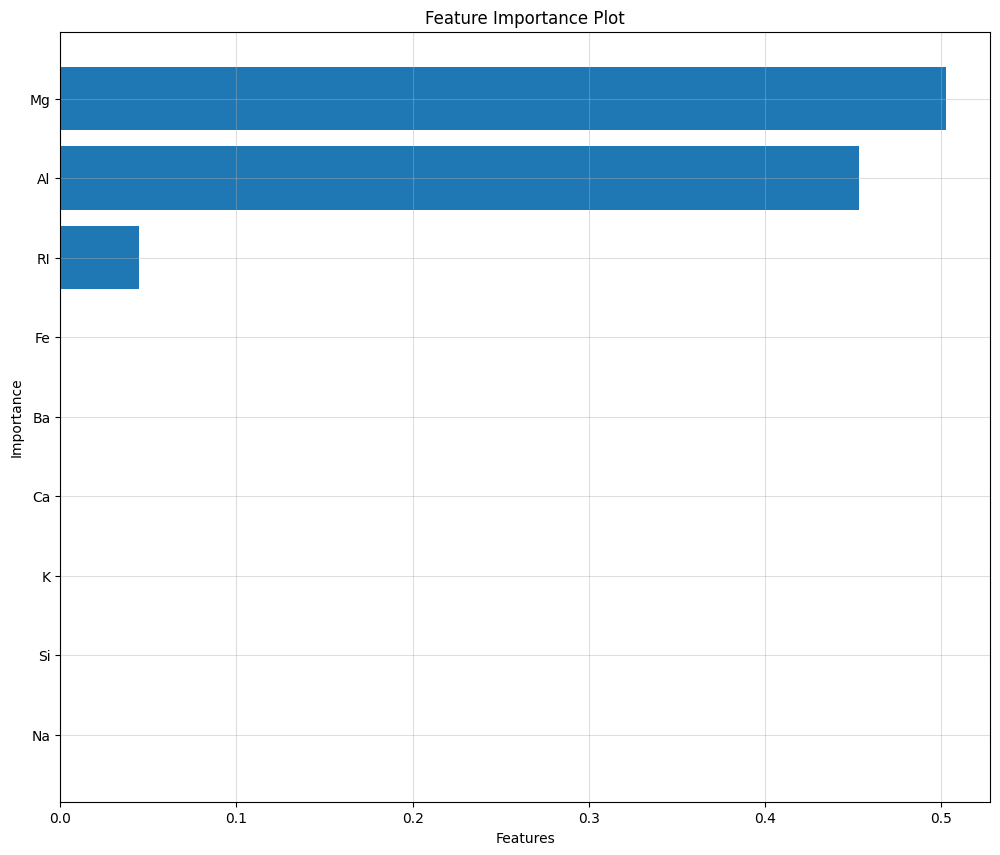

In [61]:
plt.figure(figsize=(12,10))
plt.barh(df_imp['feature'], df_imp['Importance'])
plt.title('Feature Importance Plot')
plt.xlabel('Features')    
plt.ylabel('Importance')
# plt.xticks(rotation=45)
plt.grid(True,alpha=0.4)
plt.show()

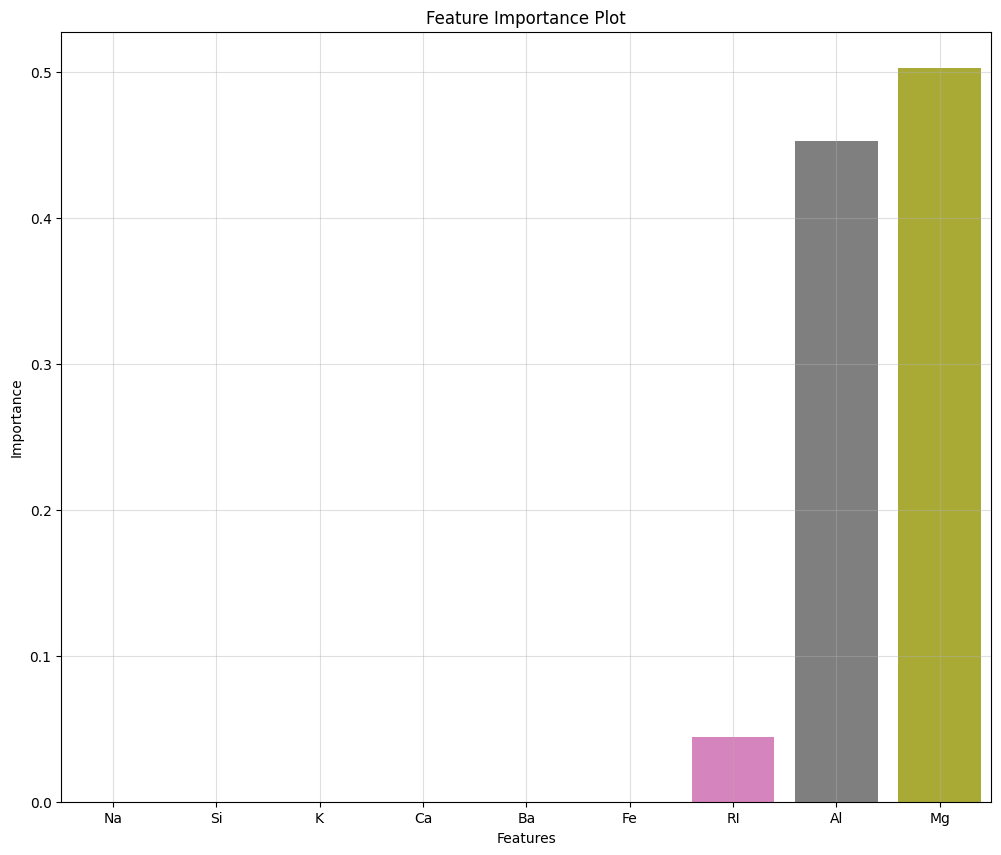

In [60]:
plt.figure(figsize=(12,10))
sns.barplot(data = df_imp,x='feature',y='Importance',hue='feature')
plt.title('Feature Importance Plot')
plt.xlabel('Features')    
plt.ylabel('Importance')
plt.grid(True,alpha=0.4)
plt.show()